# Regression

Imagine that you work for a taxi company, and that one of your customers' biggest complaints is that they don't know how much a ride will cost until it's over. That's because distance is just one of several factors from which taxi fares are calculated. You decide to do something about it by building a mobile app that customers can use when they climb into a taxi to estimate what the fare will be. To provide the smarts for the app, you intend to use the massive amounts of fare data the company has collected over the years to build a machine-learning model.

Regression models predict numeric outcomes such as the price of a car, the age of a person in a picture, or the cost of a taxi ride. Let's use a portion of a larger taxi-fare dataset from New York City to train a regression model to predict a fare amount given the time of day, the pickup and dropoff locations, and other information.

## Load and prepare data

Start by loading the dataset and shaping it so that it's suitable for use in machine learning. This dataset is a subset of a much larger dataset containing more than 100 million rows. Recently, the larger dataset was used in Kaggle's [New York City Taxi Fare Prediction](https://www.kaggle.com/c/new-york-city-taxi-fare-prediction) competition. The data requires a fair amount of prep work before it's of any use at all — something that is not uncommon in machine learning. Data scientists often find that collecting and preparing data accounts for 90% or more of their time.

In [1]:
import pandas as pd
 
df = pd.read_csv('Data/taxi-fares.csv', parse_dates=['pickup_datetime'])
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2014-06-15 17:11:00.000000107,7.0,2014-06-15 17:11:00+00:00,-73.995420,40.759662,-73.987607,40.751247,1
1,2011-03-14 22:43:00.00000095,4.9,2011-03-14 22:43:00+00:00,-73.993552,40.731110,-73.998497,40.737200,5
2,2011-02-14 15:14:00.00000067,6.1,2011-02-14 15:14:00+00:00,-73.972380,40.749527,-73.990638,40.745328,1
3,2009-10-29 11:29:00.00000040,6.9,2009-10-29 11:29:00+00:00,-73.973703,40.763542,-73.984253,40.758603,5
4,2011-07-02 10:38:00.00000028,10.5,2011-07-02 10:38:00+00:00,-73.921262,40.743615,-73.967383,40.765162,1


How many rows and columns does the dataset contain?

In [19]:
df.shape

(55368, 8)

Are any of the columns missing values?

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55368 entries, 0 to 55367
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   key                55368 non-null  object             
 1   fare_amount        55368 non-null  float64            
 2   pickup_datetime    55368 non-null  datetime64[ns, UTC]
 3   pickup_longitude   55368 non-null  float64            
 4   pickup_latitude    55368 non-null  float64            
 5   dropoff_longitude  55368 non-null  float64            
 6   dropoff_latitude   55368 non-null  float64            
 7   passenger_count    55368 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(1), object(1)
memory usage: 3.4+ MB


Draw a histogram showing how many rows contain a passenger count of 1, how many contain a passenger count of 2, and so on.

<Axes: xlabel='passenger_count', ylabel='count'>

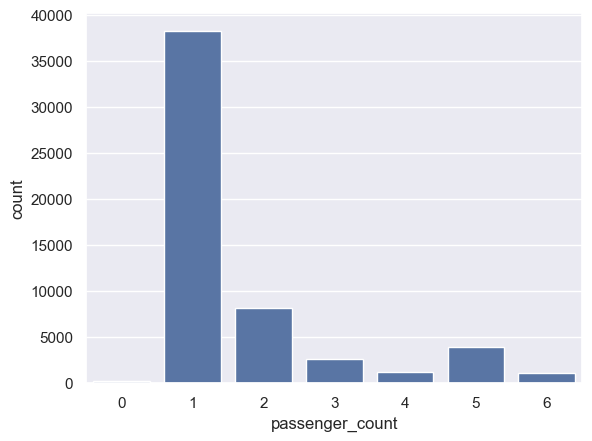

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

sns.countplot(x=df['passenger_count'])

Most of the rows in the dataset have a passenger count of 1. Remove all rows with multiple passengers and remove the "key" column from the dataset.

In [2]:
df = df[df['passenger_count'] == 1]
df = df.drop(['key', 'passenger_count'], axis=1)
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,7.0,2014-06-15 17:11:00+00:00,-73.995420,40.759662,-73.987607,40.751247
2,6.1,2011-02-14 15:14:00+00:00,-73.972380,40.749527,-73.990638,40.745328
4,10.5,2011-07-02 10:38:00+00:00,-73.921262,40.743615,-73.967383,40.765162
5,15.3,2011-12-09 20:03:00+00:00,-73.973500,40.792610,-73.936035,40.856548
8,7.7,2011-04-02 01:05:15+00:00,-73.979564,40.735405,-73.955686,40.768065


How many rows and columns are left in the dataset?

In [58]:
df.shape

(38233, 6)

Find out how much influence input variables such as `latitude` and `longitude` have on the values in the "fare_amount" column.

In [3]:
corr_matrix = df.corr()
corr_matrix['fare_amount'].sort_values(ascending=False)

fare_amount          1.000000
pickup_datetime      0.115992
dropoff_longitude    0.020438
pickup_longitude     0.015742
pickup_latitude     -0.015915
dropoff_latitude    -0.021711
Name: fare_amount, dtype: float64

The numbers don't look very encouraging. Latitudes and longitudes have little to do with fare amounts, at least in their present form. And yet intuitively, they should have a *lot* do with fare amounts since they specify starting and ending points and longer rides incur higher fares.

Now comes the fun part: creating whole new columns of data that have more impact on the outcome — columns whose values are computed from values in other columns. Add columns specifying the day of the week (0=Monday, 1=Sunday, and so on), the hour of the day that the passenger was picked up (0-23), and the distance (through the air, not on the street) in miles that the ride covered. To compute distances, this code assumes that most rides are short and that it is therefore safe to ignore the curvature of the earth.

In [6]:
import datetime as dt
import pandas as pd
import numpy as np

df['day_of_week_name'] = df['pickup_datetime'].dt.day_name() #sanity ccheck
df['day_of_week_int'] = df['pickup_datetime'].dt.weekday
#distance = between pickup and dropoff
# Trips are short, so the straight-line distance is usually a good predictor of fare.
# Using Haversine instead of approximate Pythagoras gives slightly more accurate distances


def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df['distance_km'] = haversine_np(
    df['pickup_latitude'].values,
    df['pickup_longitude'].values,
    df['dropoff_latitude'].values,
    df['dropoff_longitude'].values
)

df['pick_up_time'] = df['pickup_datetime'].dt.hour


# create a column withe time of pick up classes such as morning, afternoon, evening, night using integers

def time_of_day(hour):
    if 5 <= hour < 12:
        return '0' # morning
    elif 12 <= hour < 17:
        return '1' # afternoon
    elif 17 <= hour < 21:
        return '2' # evening
    else:
        return '3' # night
    
df['time_of_day'] = df['pick_up_time'].apply(time_of_day)

In [7]:
df_for_modelling = df.drop(columns=['pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'day_of_week_name'])
df_for_modelling.head()

,fare_amount,day_of_week_int,distance_km,pick_up_time,time_of_day
0,7.0,6,1.143954,17,2
2,6.1,0,1.607373,15,1
4,10.5,5,4.564266,10,0
5,15.3,4,7.777136,20,2
8,7.7,5,4.151423,1,3


In [8]:
corr_matrix = df_for_modelling.corr()
corr_matrix['fare_amount'].sort_values(ascending=False)

fare_amount        1.000000
distance_km        0.045156
time_of_day        0.011785
day_of_week_int    0.009196
pick_up_time      -0.019722
Name: fare_amount, dtype: float64

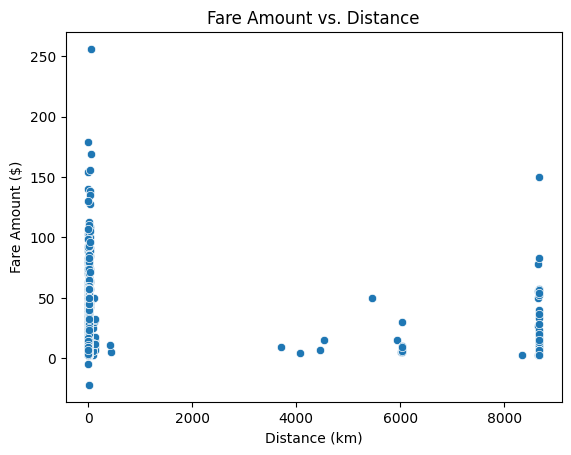

In [ ]:
#visualizations
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='distance_km', y='fare_amount', data=df)
plt.title("Fare Amount vs. Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount ($)")
plt.show()

# find and remove outliers

In [12]:
df["distance_km"].describe()


count    38233.000000
mean        20.521101
std        378.436172
min          0.000000
25%          1.204244
50%          2.110447
75%          3.821421
max       8670.083093
Name: distance_km, dtype: float64

In [16]:
Q1 = df_for_modelling['distance_km'].quantile(0.25)
Q3 = df_for_modelling['distance_km'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

df_for_modelling = df_for_modelling[(df_for_modelling['distance_km'] >= lower_limit) & (df_for_modelling['distance_km'] <= upper_limit)]

df_for_modelling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33834 entries, 0 to 55367
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fare_amount      33834 non-null  float64
 1   day_of_week_int  33834 non-null  int32  
 2   distance_km      33834 non-null  float64
 3   pick_up_time     33834 non-null  int32  
 4   time_of_day      33834 non-null  object 
dtypes: float64(2), int32(2), object(1)
memory usage: 1.3+ MB


In [17]:
corr_matrix = df_for_modelling.corr()
corr_matrix['fare_amount'].sort_values(ascending=False)

fare_amount        1.000000
distance_km        0.508320
time_of_day        0.024167
day_of_week_int    0.003470
pick_up_time       0.003238
Name: fare_amount, dtype: float64

In [18]:
df_for_modelling['is_weekend'] = df_for_modelling['day_of_week_int'].isin([5,6]).astype(int)
df_for_modelling['is_rush_hour'] = df_for_modelling['pick_up_time'].between(7,9) | df_for_modelling['pick_up_time'].between(16,18)
df_for_modelling['is_rush_hour'] = df_for_modelling['is_rush_hour'].astype(int)
df_for_modelling.head()

/var/folders/b8/6zghcv8j20s1nfnvqpkg2rmh0000gn/T/ipykernel_50031/4054348856.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_modelling['is_weekend'] = df_for_modelling['day_of_week_int'].isin([5,6]).astype(int)
/var/folders/b8/6zghcv8j20s1nfnvqpkg2rmh0000gn/T/ipykernel_50031/4054348856.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_modelling['is_rush_hour'] = df_for_modelling['pick_up_time'].between(7,9) | df_for_modelling['pick_up_time'].between(16,18)
/var/folders/b8/6zghcv8j20s1nfnv

,fare_amount,day_of_week_int,distance_km,pick_up_time,time_of_day,is_weekend,is_rush_hour
0,7.0,6,1.143954,17,2,1,1
2,6.1,0,1.607373,15,1,0,0
4,10.5,5,4.564266,10,0,1,0
8,7.7,5,4.151423,1,3,1,0
9,8.9,3,2.133193,16,1,0,1


In [19]:
corr_matrix = df_for_modelling.corr()
corr_matrix['fare_amount'].sort_values(ascending=False)

fare_amount        1.000000
distance_km        0.508320
time_of_day        0.024167
day_of_week_int    0.003470
pick_up_time       0.003238
is_rush_hour      -0.006757
is_weekend        -0.008047
Name: fare_amount, dtype: float64

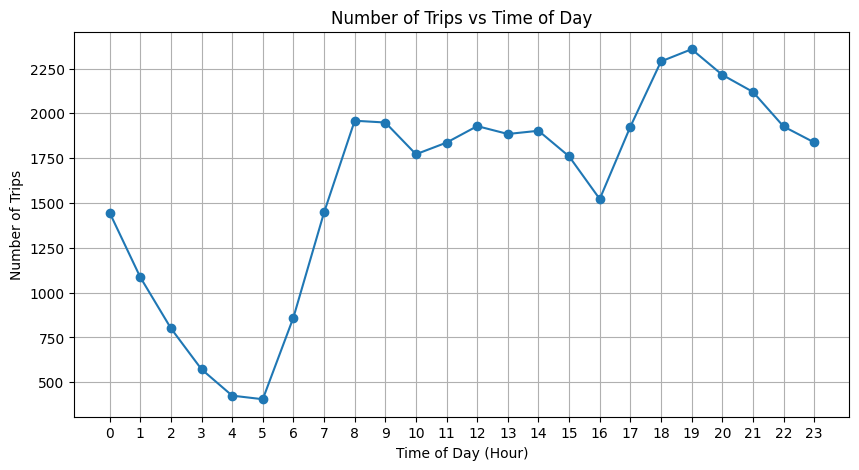

In [21]:
trip_counts = df['pick_up_time'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10,5))
plt.plot(trip_counts.index, trip_counts.values, marker='o')
plt.xlabel('Time of Day (Hour)')
plt.ylabel('Number of Trips')
plt.title('Number of Trips vs Time of Day')
plt.xticks(range(0,24))  # show all hours
plt.grid(True)
plt.show()

In [22]:
df_for_modelling['is_weekend'] = df_for_modelling['day_of_week_int'].isin([5,6]).astype(int)
df_for_modelling['is_rush_hour'] = df_for_modelling['pick_up_time'].between(7,10) | df_for_modelling['pick_up_time'].between(16,20)
df_for_modelling['is_rush_hour'] = df_for_modelling['is_rush_hour'].astype(int)
df_for_modelling.head()

/var/folders/b8/6zghcv8j20s1nfnvqpkg2rmh0000gn/T/ipykernel_50031/2048875440.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_modelling['is_weekend'] = df_for_modelling['day_of_week_int'].isin([5,6]).astype(int)
/var/folders/b8/6zghcv8j20s1nfnvqpkg2rmh0000gn/T/ipykernel_50031/2048875440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_modelling['is_rush_hour'] = df_for_modelling['pick_up_time'].between(7,10) | df_for_modelling['pick_up_time'].between(16,20)
/var/folders/b8/6zghcv8j20s1nfn

,fare_amount,day_of_week_int,distance_km,pick_up_time,time_of_day,is_weekend,is_rush_hour
0,7.0,6,1.143954,17,2,1,1
2,6.1,0,1.607373,15,1,0,0
4,10.5,5,4.564266,10,0,1,1
8,7.7,5,4.151423,1,3,1,0
9,8.9,3,2.133193,16,1,0,1


In [23]:
corr_matrix = df_for_modelling.corr()
corr_matrix['fare_amount'].sort_values(ascending=False)

fare_amount        1.000000
distance_km        0.508320
time_of_day        0.024167
day_of_week_int    0.003470
pick_up_time       0.003238
is_weekend        -0.008047
is_rush_hour      -0.019006
Name: fare_amount, dtype: float64

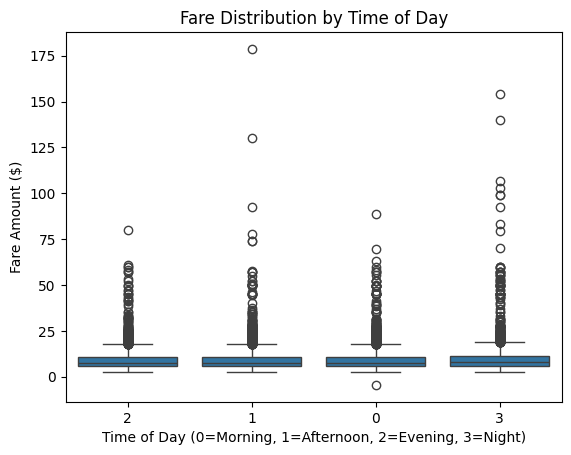

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="time_of_day", y="fare_amount", data=df_for_modelling)
plt.title("Fare Distribution by Time of Day")
plt.xlabel("Time of Day (0=Morning, 1=Afternoon, 2=Evening, 3=Night)")
plt.ylabel("Fare Amount ($)")
plt.show()

In [25]:
df_for_modelling['fare_amount'].describe()

count    33834.000000
mean         8.827855
std          5.271001
min         -4.500000
25%          5.700000
50%          7.700000
75%         10.500000
max        178.690000
Name: fare_amount, dtype: float64

In [26]:
Q1 = df_for_modelling['fare_amount'].quantile(0.25)
Q3 = df_for_modelling['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR
df_for_modelling = df_for_modelling[(df_for_modelling['fare_amount'] >= lower_limit) & (df_for_modelling['fare_amount'] <= upper_limit)]
df_for_modelling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32557 entries, 0 to 55367
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fare_amount      32557 non-null  float64
 1   day_of_week_int  32557 non-null  int32  
 2   distance_km      32557 non-null  float64
 3   pick_up_time     32557 non-null  int32  
 4   time_of_day      32557 non-null  object 
 5   is_weekend       32557 non-null  int64  
 6   is_rush_hour     32557 non-null  int64  
dtypes: float64(2), int32(2), int64(2), object(1)
memory usage: 1.7+ MB


In [27]:
corr_matrix = df_for_modelling.corr()
corr_matrix['fare_amount'].sort_values(ascending=False)

fare_amount        1.000000
distance_km        0.754851
time_of_day        0.032215
pick_up_time       0.014746
day_of_week_int    0.009433
is_weekend        -0.003600
is_rush_hour      -0.010447
Name: fare_amount, dtype: float64

After removing otliers there is a strong correlation between distance and fare. Now lwts train a regressor



In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

x = df_for_modelling.drop(['fare_amount'], axis=1)
y = df_for_modelling['fare_amount']
 
model1 = LinearRegression()
cross_val_score(model, x, y, cv=5).mean()

np.float64(0.5733779110793129)

In [30]:
from sklearn.ensemble import RandomForestRegressor
 
model2 = RandomForestRegressor(random_state=0)
cross_val_score(model2, x, y, cv=5).mean()

np.float64(0.5574381431135546)

In [31]:
from sklearn.ensemble import GradientBoostingRegressor
 
model = GradientBoostingRegressor(random_state=0)
cross_val_score(model, x, y, cv=5).mean()

np.float64(0.6302476240297065)

| Model                 | How It Builds Trees          | How It Learns              | Strengths.                |weaknesses
| --------------------- | ---------------------------- | -------------------------- | ------------------------- | ------------------------------------ |
| **Decision Tree**     | One tree                     | Single model               | Easy to understand        | Overfits easily                      |
| **Random Forest**     | Many trees (independent)     | Averages predictions       | Robust, stable            | Slower, less interpretable           |
| **Gradient Boosting** | Sequential trees             | Each fixes previous errors | Very accurate             | Slower, can overfit                  |
| **XGBoost**           | Sequential trees (optimized) | Fast gradient boosting     | Super accurate, efficient | Requires extra library, more complex |


In [ ]:
# Required imports
import pandas as pd  # for handling data
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor  # XGBoost model
import scipy.stats as stats  # for generating random distributions for hyperparameters

# Split data into training and testing sets
# X_train, y_train -> used for model training
# X_test, y_test -> reserved for final evaluation
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Define models and their hyperparameter distributions for RandomizedSearchCV
models = {
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=0),  # Gradient Boosting Regressor
        'params': {
            'n_estimators': stats.randint(100, 500),         # Number of trees
            'learning_rate': stats.uniform(0.01, 0.2),      # Shrinkage factor
            'max_depth': stats.randint(3, 6),               # Max tree depth
            'min_samples_split': stats.randint(2, 10),      # Min samples to split node
            'min_samples_leaf': stats.randint(1, 5),        # Min samples per leaf
            'subsample': stats.uniform(0.7, 0.3)           # Fraction of samples per tree
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=0),    # Random Forest Regressor
        'params': {
            'n_estimators': stats.randint(100, 500),       # Number of trees
            'max_depth': stats.randint(3, 10),             # Max tree depth
            'min_samples_split': stats.randint(2, 10),    # Min samples to split node
            'min_samples_leaf': stats.randint(1, 5),      # Min samples per leaf
            'max_features': ['auto', 'sqrt', 'log2', None] # Number of features considered at split
        }
    },
    'XGBoost': {
        'model': XGBRegressor(objective='reg:squarederror', random_state=0),  # XGBoost Regressor
        'params': {
            'n_estimators': stats.randint(100, 500),       # Number of trees
            'learning_rate': stats.uniform(0.01, 0.2),    # Shrinkage factor
            'max_depth': stats.randint(3, 6),             # Max tree depth
            'subsample': stats.uniform(0.7, 1.0),         # Fraction of samples per tree
            'colsample_bytree': stats.uniform(0.7, 1.0)   # Fraction of features per tree
        }
    }
}

# Dictionary to store the results of each model
best_models = {}

# Loop through each model
for name, mp in models.items():
    print(f"Running RandomizedSearchCV for {name}...")
    
    # Create RandomizedSearchCV object for hyperparameter tuning
    # n_iter=30 -> 30 random combinations per model
    random_search = RandomizedSearchCV(
        estimator=mp['model'],                # Model to tune
        param_distributions=mp['params'],    # Hyperparameter distributions
        n_iter=30,                            # Number of parameter settings sampled
        cv=5,                                 # 5-fold cross-validation
        scoring='r2',                         # Evaluation metric: R²
        n_jobs=-1,                            # Use all CPU cores
        verbose=1,                            # Print progress
        random_state=0                        # For reproducibility
    )
    
    # Fit RandomizedSearchCV on training data
    random_search.fit(X_train, y_train)
    
    # Store the best estimator, score, and hyperparameters in best_models dictionary
    best_models[name] = {
        'best_estimator': random_search.best_estimator_,
        'best_score': random_search.best_score_,
        'best_params': random_search.best_params_
    }
    
    print(f"{name} done. Best CV R2: {random_search.best_score_:.4f}\n")

# Find the overall best model by comparing CV R² scores
best_model_name = max(best_models, key=lambda k: best_models[k]['best_score'])

# Print results for the best model
print("Best model overall:", best_model_name)
print("Best CV R2:", best_models[best_model_name]['best_score'])
print("Best parameters:", best_models[best_model_name]['best_params'])


Running RandomizedSearchCV for GradientBoosting...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
GradientBoosting done. Best CV R2: 0.6319

Running RandomizedSearchCV for RandomForest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/marlenepostop/Documents/Applied-Machine-Learning/myenv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
35 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/marlenepostop/Documents/Applied-Machine-Learning/myenv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/marlenepostop/Documents/Applied-Machine-Learning/myenv/lib/python3.13/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_

RandomForest done. Best CV R2: 0.6270

Running RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/marlenepostop/Documents/Applied-Machine-Learning/myenv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
140 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/marlenepostop/Documents/Applied-Machine-Learning/myenv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/marlenepostop/Documents/Applied-Machine-Learning/myenv/lib/python3.13/site-packages/xgboost/core.py", line 729, in inner_f
    return func(**kwargs)

XGBoost done. Best CV R2: 0.6293

Best model overall: GradientBoosting
Best CV R2: 0.6318614905742428
Best parameters: {'learning_rate': np.float64(0.049316472336010705), 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 194, 'subsample': np.float64(0.7291303827379183)}


In [35]:
best_model = best_models['GradientBoosting']['best_estimator']


In [36]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = best_model.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Test R²: 0.6230423980869646
Test RMSE: 1.9883425483306658


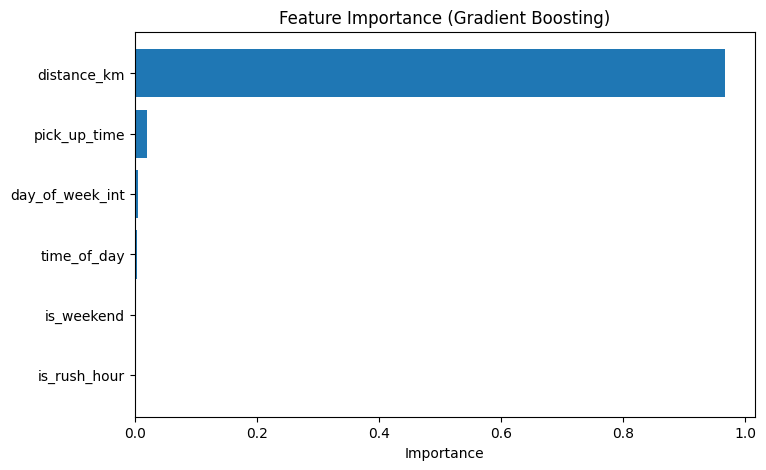

,Feature,Importance
1,distance_km,0.967289
2,pick_up_time,0.020453
0,day_of_week_int,0.006085
3,time_of_day,0.004234
4,is_weekend,0.001838
5,is_rush_hour,0.000100


In [37]:
# feature importance — this tells you which variables most influence the model’s predictions
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances
importances = best_model.feature_importances_
features = X_train.columns

# Create a sorted DataFrame
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature Importance (Gradient Boosting)')
plt.show()

feat_imp


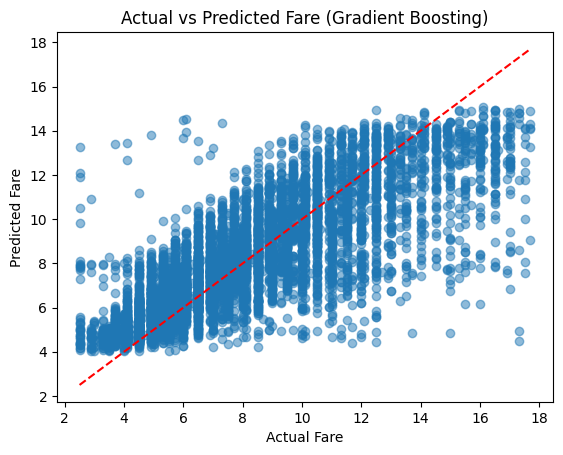

In [38]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare (Gradient Boosting)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


In [ ]:
# import datetime
# from math import sqrt
 
# for i, row in df.iterrows():
#     dt = row['pickup_datetime']
#     df.at[i, 'day_of_week'] = dt.weekday()
#     df.at[i, 'pickup_time'] = dt.hour
#     x = (row['dropoff_longitude'] - row['pickup_longitude']) * 54.6 # 1 degree == 54.6 miles
#     y = (row['dropoff_latitude'] - row['pickup_latitude']) * 69.0   # 1 degree == 69 miles
#     distance = sqrt(x**2 + y**2)
#     df.at[i, 'distance'] = distance
     
# df.head()

Remove columns that are no longer needed.

In [ ]:
# df.drop(columns=['pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'day_of_week_name'], inplace=True)
# df.head()

,fare_amount,day_of_week_int,distance_km,pick_up_time,time_of_day
0,7.0,6,1.143954,17,2
2,6.1,0,1.607373,15,1
4,10.5,5,4.564266,10,0
5,15.3,4,7.777136,20,2
8,7.7,5,4.151423,1,3


Run a correlation again.

In [ ]:
# corr_matrix = df.corr()
# corr_matrix['fare_amount'].sort_values(ascending=False)

fare_amount        1.000000
distance_km        0.045156
time_of_day        0.011785
day_of_week_int    0.009196
pick_up_time      -0.019722
Name: fare_amount, dtype: float64

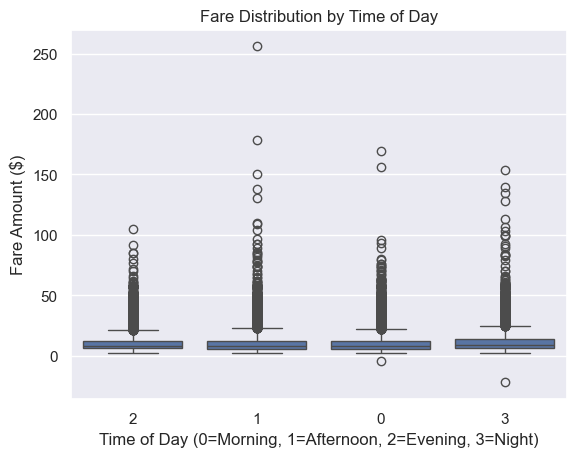

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="time_of_day", y="fare_amount", data=df)
plt.title("Fare Distribution by Time of Day")
plt.xlabel("Time of Day (0=Morning, 1=Afternoon, 2=Evening, 3=Night)")
plt.ylabel("Fare Amount ($)")
plt.show()

There still isn't a strong correlation between distance traveled and fare amount. Perhaps this will provide some clue as to why:

In [ ]:
df.describe()

The dataset contains outliers, and outliers frequently skew the results of machine-learning models (or prevent them from working at all). Filter the dataset by eliminating negative fare amounts and placing reasonable limits on fares and distance. Then run a correlation again.

In [ ]:
df = df[(df['distance_km'] > 1.0) & (df['distance_km'] < 10.0)]
df = df[(df['fare_amount'] > 0.0) & (df['fare_amount'] < 50.0)]

corr_matrix = df.corr()
corr_matrix['fare_amount'].sort_values(ascending=False)

That looks better! The correlation between the day of the week, the hour of the day, and fare amount is still weak, but let's leave those columns in there since it makes sense that it might take longer to get from point A to point B during rush hour, or that traffic at 5:00 p.m. Friday might be different than traffic at 5:00 p.m. on Saturday.

# Train a regression model

Now it's time build a regression model and train it with the data prepared in the previous exercise. We'll try three different regression algorithms to determine which one produces the most accurate results, and use cross-validation to meaasure accuracy. Then we'll train the best model. Start with a linear-regression model.

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

x = df.drop(['fare_amount'], axis=1)
y = df['fare_amount']
 
model = LinearRegression()
cross_val_score(model, x, y, cv=5).mean()

np.float64(0.6739144699177473)

Now try a `RandomForestRegressor` with the same dataset and see how its accuracy compares.

In [45]:
from sklearn.ensemble import RandomForestRegressor
 
model = RandomForestRegressor(random_state=0)
cross_val_score(model, x, y, cv=5).mean()

np.float64(0.6423496697719189)

Assess a third model that uses `GradientBoostingRegressor`.

In [46]:
from sklearn.ensemble import GradientBoostingRegressor
 
model = GradientBoostingRegressor(random_state=0)
cross_val_score(model, x, y, cv=5).mean()

np.float64(0.6966217117926214)

The `GradientBoostingRegressor` produced the highest cross-validated coefficient of determination. Train it using the entire dataset.

In [47]:
model.fit(x, y)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


The model is now trained and ready to make predictions.

## Use the model to predict fare amounts

Finish up by using the trained model to make a pair of predictions. First, estimate what it will cost to hire a taxi for a 2-mile trip at 5:00 p.m. on Friday afternoon.

In [52]:
df.describe()

,fare_amount,day_of_week_int,distance_km,pick_up_time
count,29285.000000,29285.000000,29285.000000,29285.000000
mean,10.497855,2.954789,3.075782,13.455967
std,5.622567,1.931699,1.972375,6.495258
min,2.500000,0.000000,1.000013,0.000000
25%,6.900000,1.000000,1.611669,9.000000
50%,8.900000,3.000000,2.423926,14.000000
75%,12.500000,5.000000,3.915330,19.000000
max,49.800000,6.000000,9.991479,23.000000


In [54]:
model.predict(pd.DataFrame({ 'day_of_week_int': [4], 'distance_km': [17], 'pick_up_time': [2.0] }))

array([26.66846825])

Now predict the fare amount for a 2-mile trip taken at 5:00 p.m. one day later (on Saturday).

In [18]:
model.predict(pd.DataFrame({ 'day_of_week': [5], 'pickup_time': [17], 'distance': [2.0] }))

array([10.95309995])

Does the model predict a higher or lower fare amount for the same trip on Saturday afternoon? Does this make sense given that the data comes from a New York City cab company?